In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\Keertu\Downloads\tourism_dataset_5000.csv")
print(df.head())
print(df.shape)
print(df.info())


   Tourist ID  Age                            Interests  \
0           1   48   ['Architecture', 'Art', 'History']   
1           2   37               ['Cultural', 'Nature']   
2           3   43   ['History', 'Art', 'Architecture']   
3           4   46  ['Cultural', 'Art', 'Architecture']   
4           5   53              ['Architecture', 'Art']   

   Preferred Tour Duration  Accessibility     Site Name  \
0                        5          False  Eiffel Tower   
1                        6          False     Colosseum   
2                        6           True  Machu Picchu   
3                        8          False     Colosseum   
4                        5           True     Colosseum   

                                       Sites Visited  Tour Duration  Route ID  \
0  ['Eiffel Tower', 'Great Wall of China', 'Taj M...              7      1000   
1                            ['Great Wall of China']              1      2000   
2                                   ['Eiffel To

In [4]:
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())


        Tourist ID          Age  Preferred Tour Duration  Tour Duration  \
count  5000.000000  5000.000000               5000.00000     5000.00000   
mean   2500.500000    43.886000                  5.52280        3.97720   
std    1443.520003    15.268858                  1.71186        1.99967   
min       1.000000    18.000000                  3.00000        1.00000   
25%    1250.750000    30.000000                  4.00000        2.00000   
50%    2500.500000    44.000000                  6.00000        4.00000   
75%    3750.250000    57.000000                  7.00000        5.00000   
max    5000.000000    70.000000                  8.00000        9.00000   

           Route ID  Tourist Rating  System Response Time  \
count  5.000000e+03     5000.000000           5000.000000   
mean   2.500500e+06        3.002740              3.238802   
std    1.443520e+06        1.164353              1.016123   
min    1.000000e+03        1.000000              1.500000   
25%    1.250750e+06

In [5]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

# Create total quality score
df['total_quality_score'] = (
    df['Tourist Rating'] +
    df['Recommendation Accuracy'] +
    df['VR Experience Quality']
)

# Create total tourist experience score
df['total_experience_score'] = (
    df['Tourist Rating'] +
    df['VR Experience Quality'] +
    df['Satisfaction']
)

print(df.head())

   Tourist ID  Age                            Interests  \
0           1   48   ['Architecture', 'Art', 'History']   
1           2   37               ['Cultural', 'Nature']   
2           3   43   ['History', 'Art', 'Architecture']   
3           4   46  ['Cultural', 'Art', 'Architecture']   
4           5   53              ['Architecture', 'Art']   

   Preferred Tour Duration  Accessibility     Site Name  \
0                        5          False  Eiffel Tower   
1                        6          False     Colosseum   
2                        6           True  Machu Picchu   
3                        8          False     Colosseum   
4                        5           True     Colosseum   

                                       Sites Visited  Tour Duration  Route ID  \
0  ['Eiffel Tower', 'Great Wall of China', 'Taj M...              7      1000   
1                            ['Great Wall of China']              1      2000   
2                                   ['Eiffel To

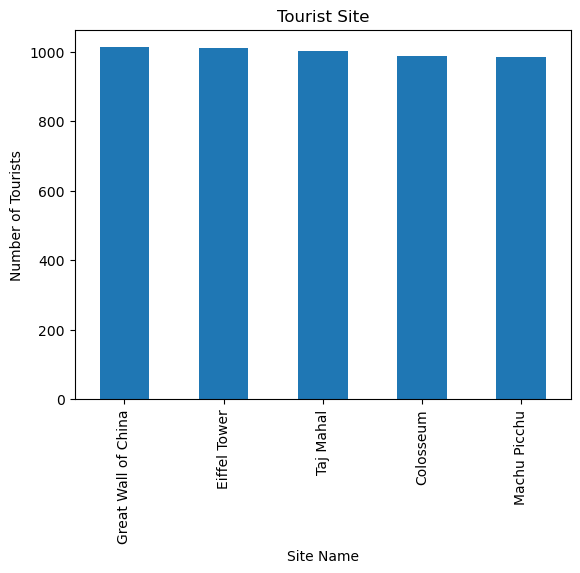

In [6]:
# Tourist Site

df['Site Name'].value_counts().plot(kind='bar')

plt.title("Tourist Site")

plt.xlabel("Site Name")

plt.ylabel("Number of Tourists")

plt.show()

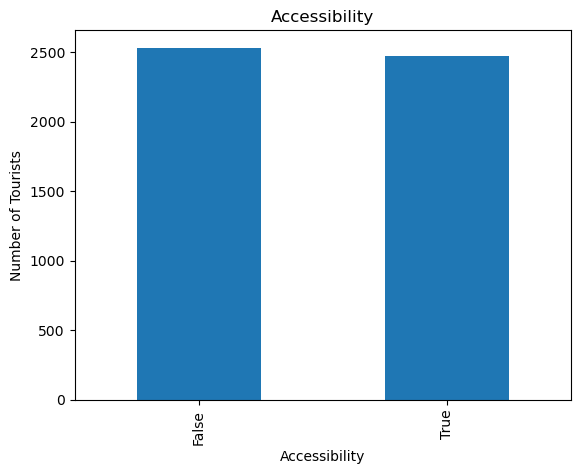

In [7]:
# Accessibility

df['Accessibility'].value_counts().plot(kind='bar')

plt.title("Accessibility")

plt.xlabel("Accessibility")

plt.ylabel("Number of Tourists")

plt.show()

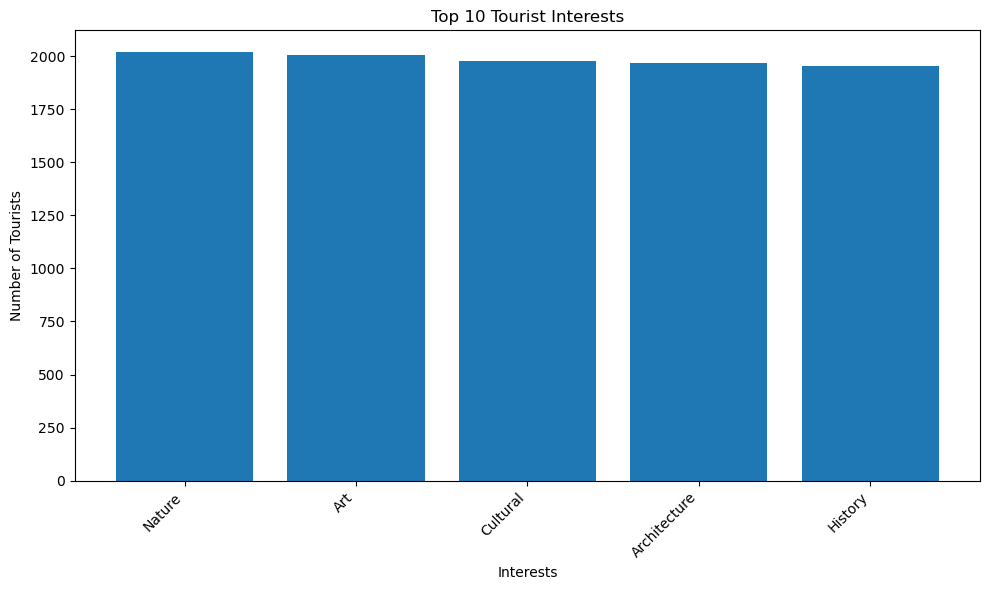

In [9]:
import ast
import matplotlib.pyplot as plt

# Convert Interests from string to list
df['Interests'] = df['Interests'].apply(ast.literal_eval)

# Separate individual interests
all_interests = df['Interests'].explode()

# Count each interest
interest_counts = all_interests.value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(interest_counts.index, interest_counts.values)

plt.title("Top 10 Tourist Interests")
plt.xlabel("Interests")
plt.ylabel("Number of Tourists")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

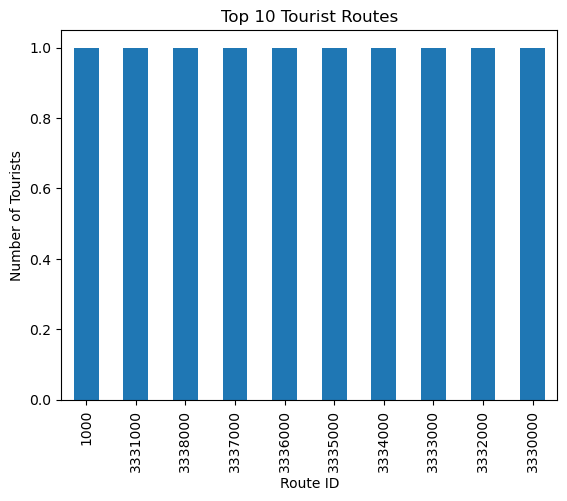

In [10]:
df['Route ID'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Tourist Routes")

plt.xlabel("Route ID")

plt.ylabel("Number of Tourists")

plt.show()

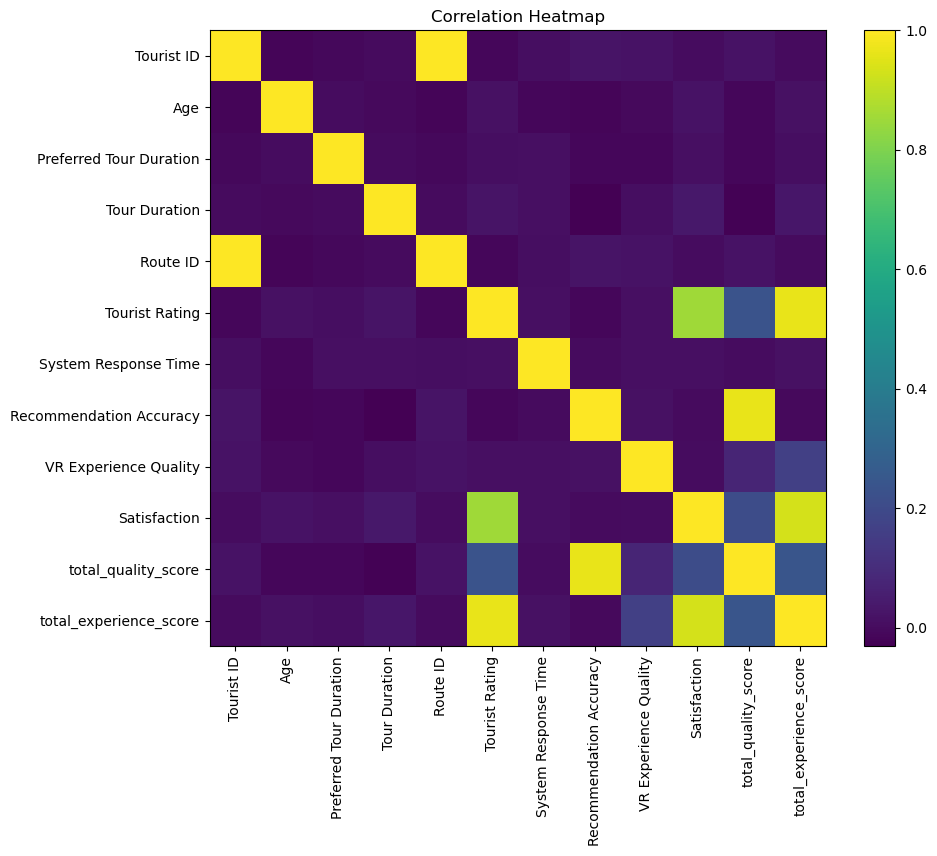

In [11]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [13]:
# Remove duplicate records
# Exclude columns containing lists
df.drop_duplicates(
    subset=[col for col in df.columns if col not in ['Interests', 'Tour Duration']],
    inplace=True
)

# Create total quality score
df['total_quality_score'] = (
    df['Tourist Rating'] +
    df['Recommendation Accuracy'] +
    df['VR Experience Quality']
)

# Create total tourist experience score
df['total_experience_score'] = (
    df['Tourist Rating'] +
    df['VR Experience Quality'] +
    df['Satisfaction']
)

print(df.head())

   Tourist ID  Age                      Interests  Preferred Tour Duration  \
0           1   48   [Architecture, Art, History]                        5   
1           2   37             [Cultural, Nature]                        6   
2           3   43   [History, Art, Architecture]                        6   
3           4   46  [Cultural, Art, Architecture]                        8   
4           5   53            [Architecture, Art]                        5   

   Accessibility     Site Name  \
0          False  Eiffel Tower   
1          False     Colosseum   
2           True  Machu Picchu   
3          False     Colosseum   
4           True     Colosseum   

                                       Sites Visited  Tour Duration  Route ID  \
0  ['Eiffel Tower', 'Great Wall of China', 'Taj M...              7      1000   
1                            ['Great Wall of China']              1      2000   
2                                   ['Eiffel Tower']              2      3000   
3 

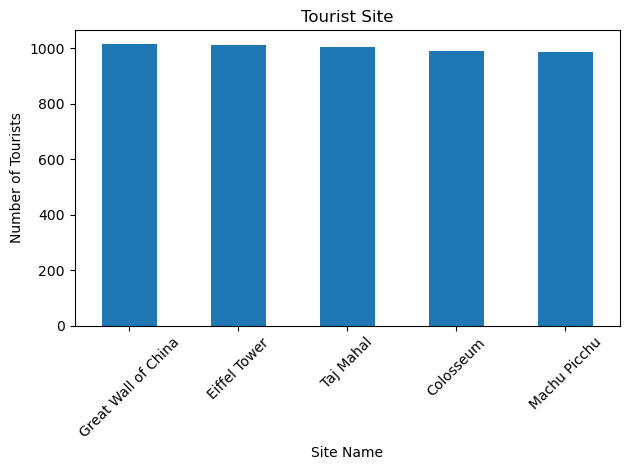

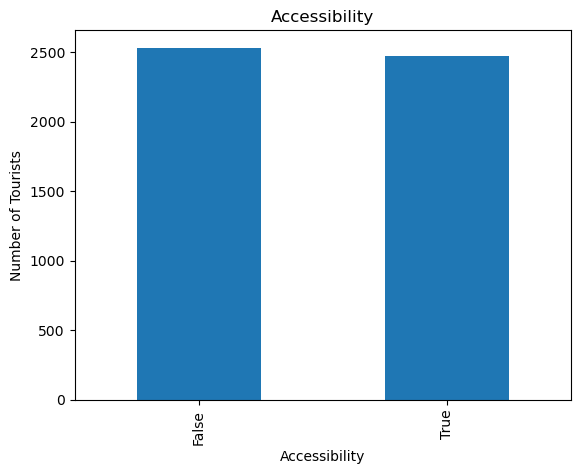

ValueError: malformed node or string: ['Architecture', 'Art', 'History']

In [15]:
df['Site Name'].value_counts().plot(kind='bar')
plt.title("Tourist Site")
plt.xlabel("Site Name")
plt.ylabel("Number of Tourists")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Accessibility
df['Accessibility'].value_counts().plot(kind='bar')
plt.title("Accessibility")
plt.xlabel("Accessibility")
plt.ylabel("Number of Tourists")
plt.show()


# Tourist Interests
df['Interests'] = df['Interests'].apply(ast.literal_eval)

# Tourist Interests
all_interests = df['Interests'].explode()

interest_counts = all_interests.value_counts().head(10)

interest_counts.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Tourist Interests')
plt.xlabel('Interests')
plt.ylabel('Number of Tourists')
plt.xticks(rotation=45)
plt.show()


# Top 10 Tourist Routes
df['Route ID'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Tourist Routes")
plt.xlabel("Route ID")
plt.ylabel("Number of Tourists")
plt.show()